<a href="https://colab.research.google.com/github/prajwoldahal/AI-and-ML/blob/main/W08_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trump Tweet Sentiment Classification

End-to-end NLP pipeline: text cleaning → TF-IDF → multi-model evaluation.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)



# Download required NLTK resources
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()




## 1. Text Cleaning Pipeline

In [ ]:
def text_cleaning_pipeline(text: str, rule: str = "lemmatize") -> str:
    """
    Full NLP preprocessing pipeline for tweet text.

    Steps:
        1. Lowercase
        2. Remove URLs
        3. Remove emojis (non-ASCII unicode)
        4. Remove mentions (@user) and hashtag symbols
        5. Remove punctuation & special characters
        6. Tokenize (whitespace split)
        7. Remove stopwords
        8. Lemmatize OR stem based on `rule`

    Args:
        text : raw tweet string
        rule : 'lemmatize' (default) | 'stem'

    Returns:
        Cleaned string of space-joined tokens
    """
    # 1. Lowercase
    data = text.lower()

    # 2. Remove URLs  (http/https/www variants)
    data = re.sub(r"https?://\S+|www\.\S+", "", data)

    # 3. Remove emojis / non-ASCII unicode
    data = data.encode("ascii", "ignore").decode("ascii")

    # 4. Remove Twitter mentions and hashtag symbols (keep the word)
    data = re.sub(r"@\w+", "", data)          # strip full mention
    data = re.sub(r"#", "", data)              # strip # but keep word

    # 5. Remove all non-alphabetic characters
    data = re.sub(r"[^a-z\s]", "", data)

    # 6. Tokenize
    tokens = data.split()

    # 7. Remove stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS]

    # 8. Normalisation
    if rule == "lemmatize":
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    elif rule == "stem":
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        print("Pick between 'lemmatize' or 'stem'")

    return " ".join(tokens)


# Quick sanity check
sample = "RT @JohnLeguizamo: #trump not draining swamp! https://t.co/abc123 💥"
print("Raw    :", sample)
print("Cleaned:", text_cleaning_pipeline(sample))


Raw    : RT @JohnLeguizamo: #trump not draining swamp! https://t.co/abc123 💥
Cleaned: rt trump draining swamp


## 2. Load & Explore Dataset

In [ ]:

DATA_PATH = "/content/trum_tweet_sentiment_analysis.csv"

df = pd.read_csv(DATA_PATH)

df.rename(columns={"Sentiment": "label"}, inplace=True)

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nNull values    :\n{df.isnull().sum()}")
df.head(3)


Dataset shape  : (1850123, 2)
Columns        : ['text', 'label']

Class distribution:
label
0    1244211
1     605912
Name: count, dtype: int64

Null values    :
text     0
label    0
dtype: int64


,text,label
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1


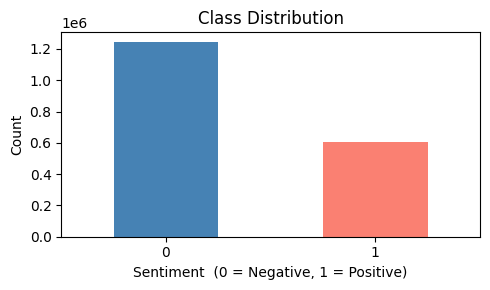

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
df["label"].value_counts().plot(kind="bar", color=["steelblue", "salmon"], ax=ax)
ax.set_title("Class Distribution")
ax.set_xlabel("Sentiment  (0 = Negative, 1 = Positive)")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


## 3. Text Cleaning

> The full dataset has ~1.85 M rows. We sample **100 k** rows for faster prototyping; remove the `.sample()` call to run on all data.

In [ ]:
SAMPLE_SIZE = 100_000

if SAMPLE_SIZE:
    df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_sample = df.copy()

print(f"Working with {len(df_sample):,} rows")

# Drop nulls in text column
df_sample.dropna(subset=["text"], inplace=True)

# Apply cleaning pipeline
print("Cleaning tweets … (this may take ~30–60 s)")
df_sample["clean_text"] = df_sample["text"].apply(
    lambda t: text_cleaning_pipeline(t, rule="lemmatize")
)

# Drop rows that became empty after cleaning
df_sample = df_sample[df_sample["clean_text"].str.strip().astype(bool)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_sample):,}")
df_sample[["text", "clean_text", "label"]].head(3)


Working with 100,000 rows
Cleaning tweets … (this may take ~30–60 s)
Rows after cleaning: 99,998


,text,clean_text,label
0,RT @EthandeMarsi: I don't understand why adult...,rt dont understand adult would mean kid age il...,0
1,RT @atrumptastrophe: Suddenly that 3AM call be...,rt suddenly call trump flynn last week value d...,0
2,@RealJeremyNolt~'going after Trump loyalists'f...,going trump loyalistsfor good reasonstrump fam...,1


## 4. Train / Test Split

In [ ]:
df_sample.dropna(subset=["label"], inplace=True)
X = df_sample["clean_text"]
y = df_sample["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {len(X_train):,}  |  Test size : {len(X_test):,}")
print(f"Train class dist:\n{y_train.value_counts()}")

Train size : 79,998  |  Test size : 20,000
Train class dist:
label
0    53681
1    26317
Name: count, dtype: int64


## 5. TF-IDF Vectorisation

`max_features=50_000` keeps only the 50 k most informative unigrams+bigrams.

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")


TF-IDF matrix shape (train): (79998, 50000)
TF-IDF matrix shape (test) : (20000, 50000)


## 6. Model Training & Evaluation

In [ ]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train model, print report, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, target_names=["Negative", "Positive"]))


    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)
    auc = roc_auc_score(y_te, y_score)
    print(f"  ROC-AUC: {auc:.4f}")

    return {"model": model_name, "y_pred": y_pred, "auc": auc, "model_obj": model}


In [ ]:
# Logistic Regression
lr_results = evaluate_model(
    LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    "Logistic Regression"
)



  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.90      0.96      0.93     13421
    Positive       0.92      0.78      0.84      6579

    accuracy                           0.90     20000
   macro avg       0.91      0.87      0.89     20000
weighted avg       0.90      0.90      0.90     20000

  ROC-AUC: 0.9649


## 7. Confusion Matrices

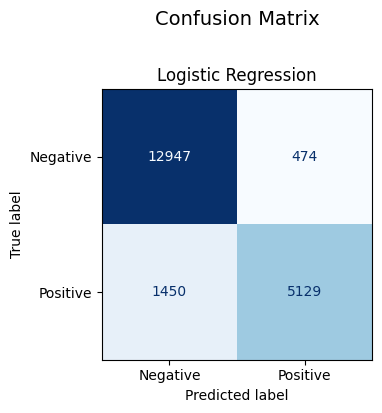

In [ ]:
all_results = [lr_results]
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

for res in all_results:
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(res["model"])

plt.suptitle("Confusion Matrix", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Top Informative Features (Logistic Regression)

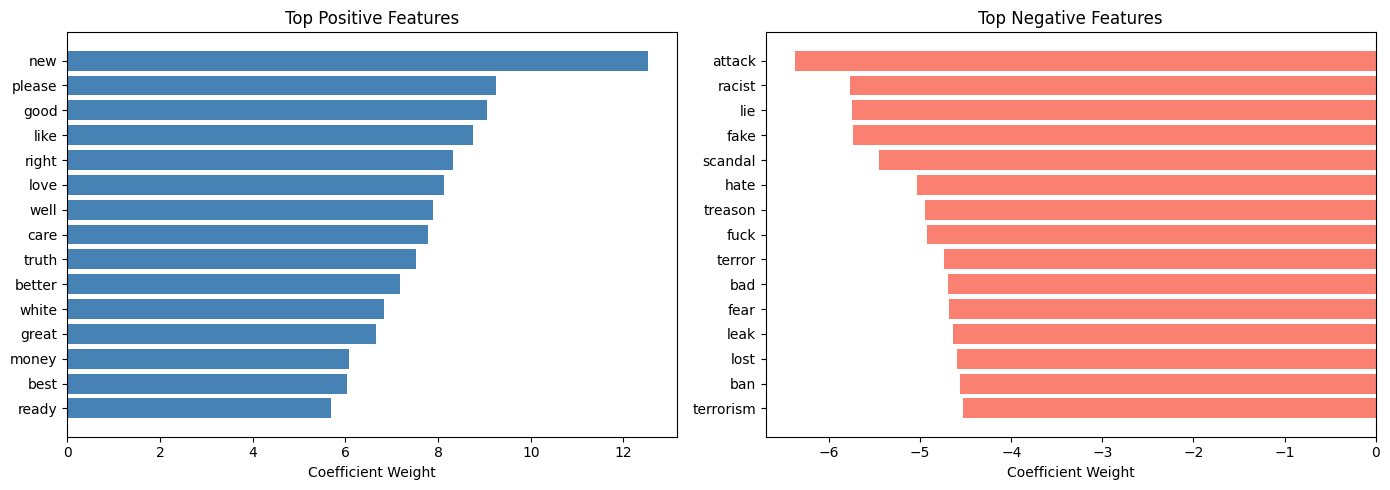

In [ ]:
feature_names = vectorizer.get_feature_names_out()
coef = lr_results["model_obj"].coef_[0]

top_n = 15
top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, idx, title, color in [
    (axes[0], top_pos_idx, "Top Positive Features", "steelblue"),
    (axes[1], top_neg_idx, "Top Negative Features", "salmon"),
]:
    ax.barh(feature_names[idx][::-1], coef[idx][::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Coefficient Weight")

plt.tight_layout()
plt.show()


## 10. Inference on Custom Tweets

In [ ]:
best_model = lr_results["model_obj"]

test_tweets = [
     "The economy seems to be improving steadily under the current leadership.",
    "I can't believe how poorly this situation is being handled.",
    "Another speech, same promises, nothing new.",
    "Honestly, I'm impressed with the recent policy changes.",
    "This is the worst decision I've seen in years.",
    "People are overreacting to everything these days.",
    "The new reforms might actually benefit small businesses.",
    "What a joke. Totally unprofessional and embarrassing.",
    "Not sure how I feel about this yet.",
    "Finally, something that makes sense!",
    "Everything is falling apart, and nobody is taking responsibility.",
    "Great leadership during tough times.",
    "This feels like a step in the wrong direction.",
    "The announcement was okay, nothing groundbreaking.",
    "Absolutely brilliant move—well executed.",
    "I doubt this will have any real impact.",
    "Such a disappointing outcome.",
    "Credit where it's due, this was handled well.",
    "This could either go really well or really badly.",
    "Another day, another controversy."
]

for tweet in test_tweets:
    cleaned  = text_cleaning_pipeline(tweet)
    vec      = vectorizer.transform([cleaned])
    pred     = best_model.predict(vec)[0]
    label    = "Positive" if pred == 1 else "Negative"
    print(f"Tweet   : {tweet}")
    print(f"Cleaned : {cleaned}")
    print(f"Prediction → {label}\n")


Tweet   : The economy seems to be improving steadily under the current leadership.
Cleaned : economy seems improving steadily current leadership
Prediction → Negative

Tweet   : I can't believe how poorly this situation is being handled.
Cleaned : cant believe poorly situation handled
Prediction → Negative

Tweet   : Another speech, same promises, nothing new.
Cleaned : another speech promise nothing new
Prediction → Positive

Tweet   : Honestly, I'm impressed with the recent policy changes.
Cleaned : honestly im impressed recent policy change
Prediction → Positive

Tweet   : This is the worst decision I've seen in years.
Cleaned : worst decision ive seen year
Prediction → Negative

Tweet   : People are overreacting to everything these days.
Cleaned : people overreacting everything day
Prediction → Negative

Tweet   : The new reforms might actually benefit small businesses.
Cleaned : new reform might actually benefit small business
Prediction → Positive

Tweet   : What a joke. Totally 